In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score



In [2]:
# load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"
df = pd.read_csv(url)

In [3]:
df.head(4)

,842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,...,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
0,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
3,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# rename columns based on wdbc.names
columns = [
	'id_number',
	'diagnosis', # M = malignant, B = benign
]

stat_map = {
	0:'mean', 
	1:'standard_error', 
	2:'worst'
}

features = {
	0:'radius', 
	1:'texture', 
	2:'perimeter', 
	3:'area', 
	4:'smoothness', 
	5:'compactness',
	6:'concavity',
	7:'concave_points',
	8:'symmetry',
	9:'fractal_dimension'
}

other_columns = [stat_map[i] + '_' + features[j] for i in range(3) for j in range(10)]

columns.extend(other_columns)

df.columns = columns

From wdbc.names, explanation of columns

Ten real-valued features are computed for each cell nucleus:

	a) radius (mean of distances from center to points on the perimeter)
	b) texture (standard deviation of gray-scale values)
	c) perimeter
	d) area
	e) smoothness (local variation in radius lengths)
	f) compactness (perimeter^2 / area - 1.0)
	g) concavity (severity of concave portions of the contour)
	h) concave points (number of concave portions of the contour)
	i) symmetry 
	j) fractal dimension ("coastline approximation" - 1)

The mean, standard error, and "worst" or largest (mean of the three
largest values) of these features were computed for each image,
resulting in 30 features.  For instance, field 3 is Mean Radius, field
13 is Radius SE, field 23 is Worst Radius.

In [5]:
df.head()

,id_number,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
3,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
4,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440


In [6]:
# convert 'diagnosis' column to binary
diagnosis = df['diagnosis']
diagnosis = diagnosis.map({"M": 1, "B": 0})

df['diagnosis'] = diagnosis

In [7]:
df

,id_number,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
1,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
2,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
3,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
4,843786,1,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.470,23.75,103.40,741.6,0.17910,0.52490,0.5355,0.1741,0.3985,0.12440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
563,926424,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
564,926682,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
565,926954,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
566,927241,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [8]:
# train test split
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2
)

In [9]:
X_train

,id_number,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
521,91789,11.26,19.83,71.30,388.1,0.08511,0.04413,0.005067,0.005664,0.1637,...,11.93,26.43,76.38,435.9,0.1108,0.07723,0.025330,0.02832,0.2557,0.07613
255,88649001,19.55,28.77,133.60,1207.0,0.09260,0.20630,0.178400,0.114400,0.1893,...,25.05,36.27,178.60,1926.0,0.1281,0.53290,0.425100,0.19410,0.2818,0.10050
218,88119002,19.53,32.47,128.00,1223.0,0.08420,0.11300,0.114500,0.066370,0.1428,...,27.90,45.41,180.20,2477.0,0.1408,0.40970,0.399500,0.16250,0.2713,0.07568
50,857373,13.64,16.34,87.21,571.8,0.07685,0.06059,0.018570,0.017230,0.1353,...,14.67,23.19,96.08,656.7,0.1089,0.15820,0.105000,0.08586,0.2346,0.08025
14,84799002,14.54,27.54,96.73,658.8,0.11390,0.15950,0.163900,0.073640,0.2303,...,17.46,37.13,124.10,943.2,0.1678,0.65770,0.702600,0.17120,0.4218,0.13410
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,86730502,16.16,21.54,106.20,809.8,0.10080,0.12840,0.104300,0.056130,0.2160,...,19.47,31.68,129.70,1175.0,0.1395,0.30550,0.299200,0.13120,0.3480,0.07619
302,892657,10.49,18.61,66.86,334.3,0.10680,0.06678,0.022970,0.017800,0.1482,...,11.06,24.54,70.76,375.4,0.1413,0.10440,0.084230,0.06528,0.2213,0.07842
332,897137,11.25,14.78,71.38,390.0,0.08306,0.04458,0.000974,0.002941,0.1773,...,12.76,22.06,82.08,492.7,0.1166,0.09794,0.005518,0.01667,0.2815,0.07418
143,869254,10.75,14.97,68.26,355.3,0.07793,0.05139,0.022510,0.007875,0.1399,...,11.95,20.72,77.79,441.2,0.1076,0.12230,0.097550,0.03413,0.2300,0.06769


In [10]:
# check for missing values
X_train.isna().sum()

id_number                           0
mean_radius                         0
mean_texture                        0
mean_perimeter                      0
mean_area                           0
mean_smoothness                     0
mean_compactness                    0
mean_concavity                      0
mean_concave_points                 0
mean_symmetry                       0
mean_fractal_dimension              0
standard_error_radius               0
standard_error_texture              0
standard_error_perimeter            0
standard_error_area                 0
standard_error_smoothness           0
standard_error_compactness          0
standard_error_concavity            0
standard_error_concave_points       0
standard_error_symmetry             0
standard_error_fractal_dimension    0
worst_radius                        0
worst_texture                       0
worst_perimeter                     0
worst_area                          0
worst_smoothness                    0
worst_compac

In [11]:
# standardize columns of training data
scaler = StandardScaler().set_output(transform="pandas")
X_train = scaler.fit_transform(X_train)

X_train.columns = ['id_number'] + other_columns
X_train

,id_number,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
521,-0.240370,-0.816002,0.094814,-0.854591,-0.759239,-0.786756,-1.145536,-1.074393,-1.130969,-0.624363,...,-0.896387,0.092274,-0.921559,-0.777831,-0.918617,-1.111927,-1.177649,-1.311604,-0.546288,-0.420362
255,0.548911,1.541105,2.157907,1.715637,1.567804,-0.256592,1.896493,1.117387,1.691937,0.290488,...,1.822918,1.654431,2.137149,1.833800,-0.158551,1.707167,0.709218,1.225057,-0.137906,0.888515
218,0.544187,1.535419,3.011760,1.484605,1.613270,-0.851168,0.146346,0.309377,0.445025,-1.371254,...,2.413621,3.105459,2.185025,2.799512,0.399416,0.944965,0.588389,0.741534,-0.302197,-0.444530
50,-0.233546,-0.139293,-0.710576,-0.198214,-0.237224,-1.371422,-0.836775,-0.903649,-0.830703,-1.639276,...,-0.328483,-0.422095,-0.332080,-0.390845,-1.002092,-0.610990,-0.801616,-0.431163,-0.876436,-0.199082
14,0.514597,0.116605,1.874059,0.194541,0.010001,1.251082,1.018606,0.934035,0.633763,1.755679,...,0.249784,1.790961,0.506357,0.111290,1.585646,2.479267,2.018985,0.874656,2.052650,2.693122
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,0.531812,0.577222,0.489433,0.585232,0.439093,0.323827,0.435223,0.180399,0.179184,1.244649,...,0.666385,0.925742,0.673924,0.517556,0.342301,0.300311,0.114985,0.262601,0.897914,-0.417139
302,-0.233232,-1.034937,-0.186726,-1.037767,-0.912120,0.748524,-0.720662,-0.848011,-0.815905,-1.178277,...,-1.076706,-0.207774,-1.089725,-0.883867,0.421383,-0.943835,-0.899648,-0.746065,-1.084539,-0.297369
332,-0.233192,-0.818845,-1.070579,-0.851291,-0.753840,-0.931861,-1.137095,-1.126152,-1.201661,-0.138349,...,-0.724357,-0.601489,-0.750999,-0.678280,-0.663797,-0.983801,-1.271159,-1.489865,-0.142600,-0.525093
143,-0.233440,-0.961011,-1.026733,-0.980009,-0.852445,-1.294977,-1.009351,-0.853828,-1.073569,-1.474889,...,-0.892241,-0.814221,-0.879367,-0.768542,-1.059207,-0.833093,-0.836779,-1.222703,-0.948411,-0.873662


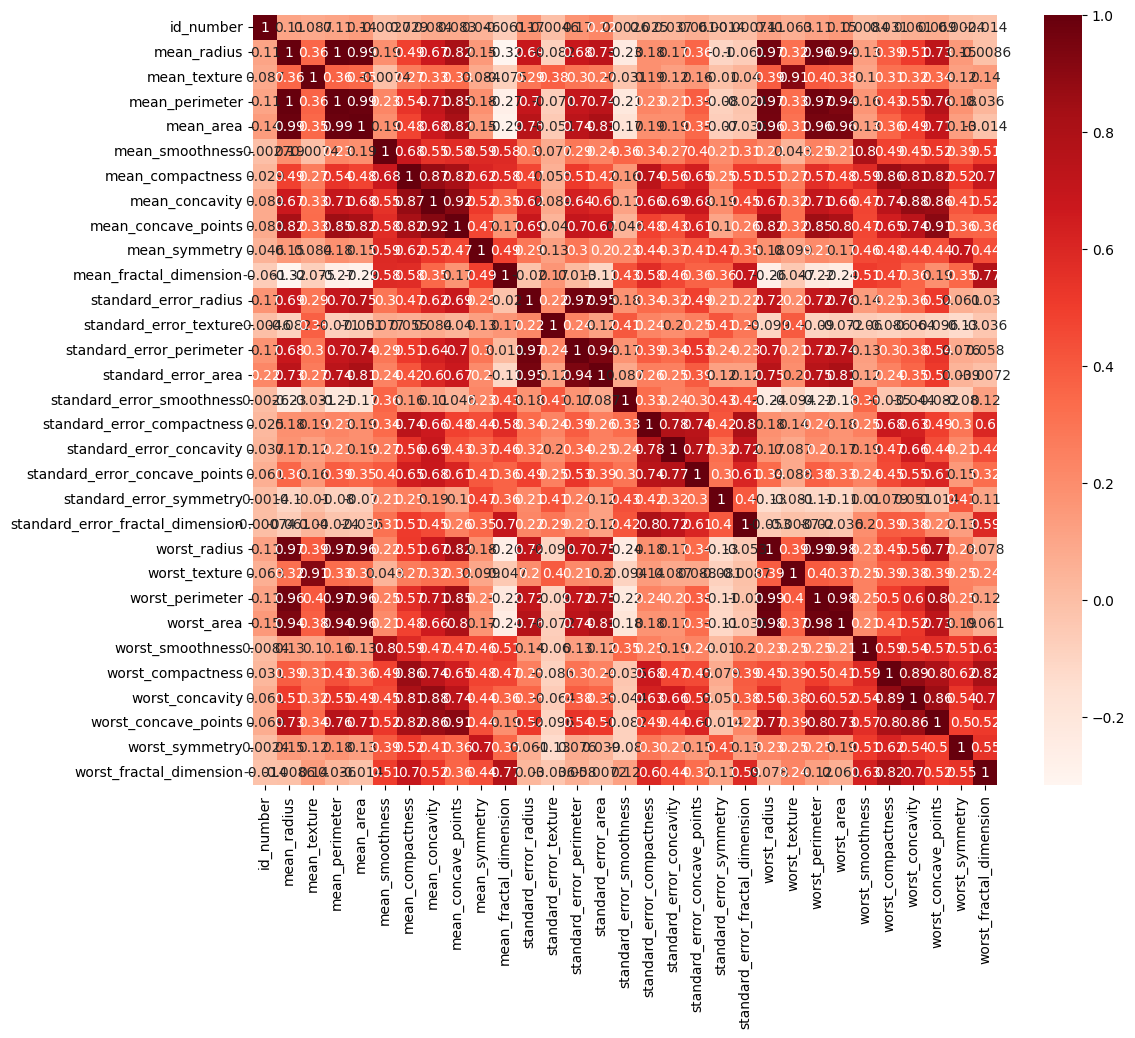

In [12]:
# plot correlation matrix
plt.figure(figsize=(12,10))
corr_matrix = X_train.corr()
sns.heatmap(corr_matrix, annot=True, cmap=plt.cm.Reds)
plt.show()

In [13]:
# drop highly correlated features
corr_matrix = corr_matrix.abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
X_train_light = X_train.drop(to_drop, axis=1)
print(f"Dropped {len(to_drop)} features: {to_drop}")

Dropped 10 features: ['mean_perimeter', 'mean_area', 'mean_concave_points', 'standard_error_perimeter', 'standard_error_area', 'worst_radius', 'worst_texture', 'worst_perimeter', 'worst_area', 'worst_concave_points']


In [14]:
# predict using logistic regression
X_test_standardized = scaler.transform(X_test)
X_test_light = X_test_standardized.drop(columns=to_drop)

model = LogisticRegression()
model.fit(X_train_light, y_train)
prediction = model.predict(X_test_light)

In [15]:
X_test_light.columns

Index(['id_number', 'mean_radius', 'mean_texture', 'mean_smoothness',
       'mean_compactness', 'mean_concavity', 'mean_symmetry',
       'mean_fractal_dimension', 'standard_error_radius',
       'standard_error_texture', 'standard_error_smoothness',
       'standard_error_compactness', 'standard_error_concavity',
       'standard_error_concave_points', 'standard_error_symmetry',
       'standard_error_fractal_dimension', 'worst_smoothness',
       'worst_compactness', 'worst_concavity', 'worst_symmetry',
       'worst_fractal_dimension'],
      dtype='object')

In [16]:
model.coef_

array([[-0.10651041,  2.21746945,  1.08950089,  0.00657227, -0.10001409,
         1.57495772,  0.0757799 , -0.71929231,  2.03469421,  0.22000698,
        -0.59905703, -0.78140001, -0.59480897,  0.62481955, -0.40662189,
        -0.6969776 ,  0.94076274,  0.14796291,  1.15892728,  0.89226346,
         0.68334558]])

In [17]:
model_coef_weights = pd.DataFrame({
    'feature':X_test_light.columns,
    'model_coefficient':model.coef_.flatten()
})

model_coef_weights

,feature,model_coefficient
0,id_number,-0.106510
1,mean_radius,2.217469
2,mean_texture,1.089501
3,mean_smoothness,0.006572
4,mean_compactness,-0.100014
5,mean_concavity,1.574958
6,mean_symmetry,0.075780
7,mean_fractal_dimension,-0.719292
8,standard_error_radius,2.034694
9,standard_error_texture,0.220007


mean_radius is the most important feature in determining whether a tumor is malignant

In [18]:
# accuracy
accuracy = (y_test == prediction).mean()
accuracy

np.float64(0.9824561403508771)

In [19]:
def confusion_matrix_and_recall(test_labels, model_predictions):
    cm = confusion_matrix(test_labels, model_predictions)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
    disp.plot(cmap='Blues')
    plt.show()

    true_positives = cm[1,1]
    false_positives = cm[0,1]
    false_negatives = cm[1,0]
    true_negatives = cm[0,0]

    actual_positives = true_positives + false_negatives
    actual_negatives = false_positives + true_negatives

    recall = true_positives / (actual_positives)
    print('recall:', recall)


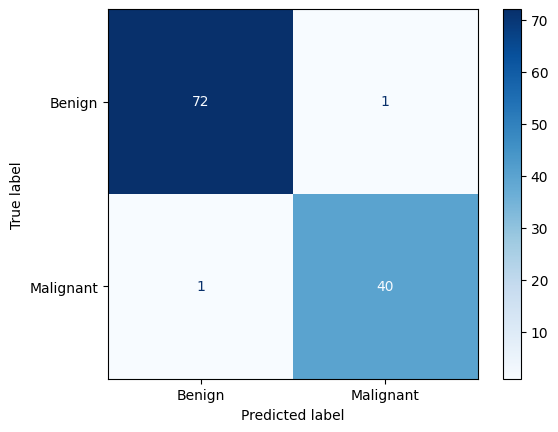

recall: 0.975609756097561


In [20]:
confusion_matrix_and_recall(y_test, prediction)

recall can be higher by adjusting threshold of when the model predicts a tumor as being malignant

use precision-recall curve to choose best threshold

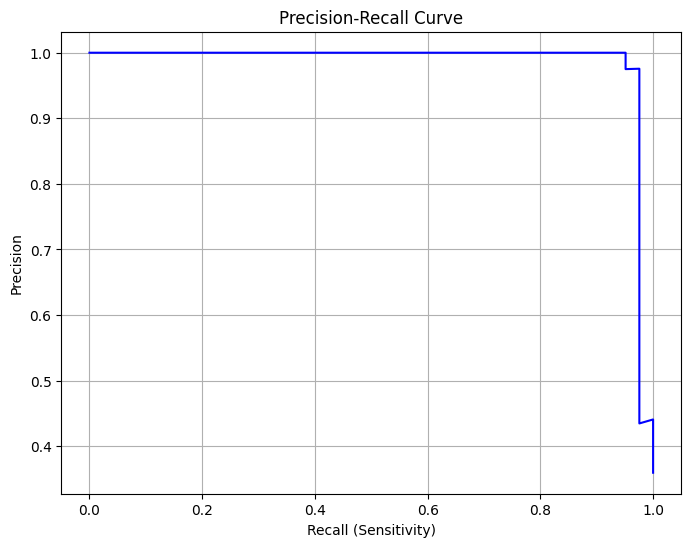

In [21]:
probs = model.predict_proba(X_test_light)[:, 1] # get the model's guesses as probabilities, then get only the probabilities of being malignant

precisions, recalls, thresholds = precision_recall_curve(y_test, probs)

plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, color='blue', label='Logistic Regression')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

In [22]:
# optimal threshold is where recall is at least 95%
target_recall = 0.95
idx = (recalls >= target_recall).argmin() - 1 # (recalls >= target_recall) returns a boolean array
# and argmin finds the index of the first false. so subtract by one to find index of the last true
opt_threshold = thresholds[idx] # get optimal threshold

print(f"To get {target_recall*100}% recall, use a threshold of: {opt_threshold:.4f}")

To get 95.0% recall, use a threshold of: 0.6487


In [25]:
# adjust threshold
probability_threshold = opt_threshold
prediction_low_threshold = (probs >= probability_threshold).astype(int)

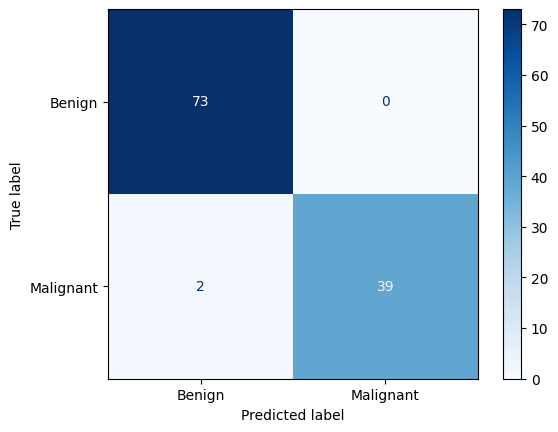

recall: 0.9512195121951219


In [26]:
confusion_matrix_and_recall(y_test, prediction_low_threshold)

In [27]:
ap_score = average_precision_score(y_test, prediction_low_threshold)
ap_score

0.9687633718442448

what about for l1 logistic regression

In [ ]:
model_l1 = LogisticRegression(penalty='l1', solver='liblinear')
model_l1.fit(X_train_light, y_train)
l1_probs = model_l1.predict_proba(X_test_light)
l1_probs = model.predict_proba(X_test_light)[:, 1] # get the model's guesses as probabilities, then get only the probabilities of being malignant

precisions, recalls, thresholds = precision_recall_curve(y_test, probs)

plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, color='blue', label='Logistic Regression')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

